In [1]:
import matplotlib.pyplot as plt
import scanpy as sc

In [2]:
visit_keep = ["PreTx", "Healthy"]

adata_bmmc = sc.read_h5ad("../../data/figure-inputs/scrna_objects/final-bmmc-processed.h5ad")
adata_bmmc = adata_bmmc[adata_bmmc.obs["label.visitDetails"].isin(visit_keep)].copy()


adata_pbmc = sc.read_h5ad("../../data/figure-inputs/scrna_objects/final-pbmc-raw.h5ad")
adata_pbmc = adata_pbmc[adata_pbmc.obs["label.visitDetails"].isin(visit_keep)].copy()

sc.pp.normalize_total(adata_pbmc)
sc.pp.log1p(adata_pbmc)

adata = adata_bmmc.concatenate(adata_pbmc, batch_key="tissue", batch_categories=["BMMC", "PBMC"])

/tmp/ipykernel_73370/231702458.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_bmmc.concatenate(adata_pbmc, batch_key="tissue", batch_categories=["BMMC", "PBMC"])


/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/anndata/_core/merge.py:1410: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [3]:
# align plasma cell names across bmmc and pbmc
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].astype(str)
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].replace(
    "Plasma (Non-malignant)", "Plasma_Normal"
)
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].replace("Plasma", "Plasma_Normal")
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].replace(
    "Plasma (Malignant)", "Plasma_Tumor"
)

In [4]:
adata.obs["group"] = (
    adata.obs["tissue"].astype(str)
    + "_"
    + adata.obs["aifi_plot_l2"].astype(str)
    + "_"
    + adata.obs["label.visitDetails"].astype(str)
)

tissues = adata.obs["tissue"].unique().tolist()
visits = adata.obs["label.visitDetails"].unique().tolist()

In [5]:
# Recruitment cell types
celltypes_ordered = [
    "CD8 T Memory",
    "Tissue Res T",
    "gdT",
    "Prolif T",
    "MAIT",
    "CD56br NK",
    "CD56dim NK",
    "Tissue Res NK",
    "Effector NK",
    "Prolif NK",
    "cDC1",
    "cDC2",
    "CD14 Mono",
    "Int Mono",
    "CD16 Mono",
    "HSPC",
    "LMPP",
    "CLP",
    "Prog B",
    "Pre B",
    "CMP",
    "Prog DC",
    "Pre Mono",
    "BaEoMaP",
    "MEP",
    "Pre Prog Ery",
    "Prog Ery",
    "Prog MK"
]

In [6]:
adata_sub = adata[adata.obs["aifi_plot_l2"].isin(celltypes_ordered)].copy()

group_order = [
    f"{t}_{ct}_{v}"
    for t in tissues
    for ct in celltypes_ordered
    for v in visits
    if f"{t}_{ct}_{v}" in adata.obs["group"].values
]

# set categorical
adata_sub.obs["group"] = adata_sub.obs["group"].astype("category")
adata_sub.obs["group"] = adata_sub.obs["group"].cat.set_categories(
    group_order, ordered=True
)

In [7]:
genes = ["XCL1", "XCR1", "CCL28", "CCR10", "CCL3", "CCR1", "CCL5", "CCR5"]

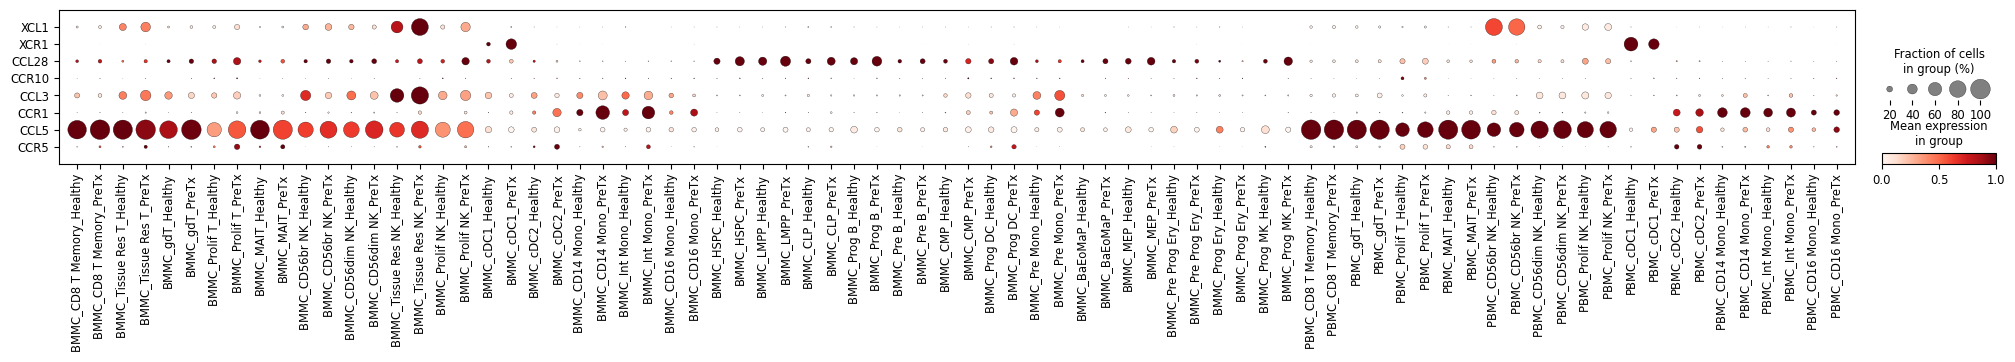

In [8]:
sc.pl.dotplot(
    adata_sub,
    var_names=genes,
    groupby="group",
    standard_scale="var",
    dendrogram=False,
    use_raw=False,
    swap_axes=True,
    show=False,
    figsize=(25, 2),
)
plt.savefig("../../data/figure-outputs/figure-2/fig_2l.pdf", dpi=200, bbox_inches="tight")